<a href="https://colab.research.google.com/github/NadeenAlaqeel625/AI-Models/blob/main/speech_to_text_whisper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

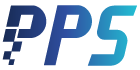

<div dir="rtl" align="right">

# نظام معالجة وتحويل الصوت إلى نص

أداة داخلية مقدّمة من **Pixel Professional Solutions** لمعالجة الملفات الصوتية وتحويل محتواها إلى نص باستخدام تقنيات الذكاء الاصطناعي ونموذج **Whisper**.

### خطوات الاستخدام

**1. تشغيل النظام**  
قم بتشغيل خلية التثبيت الأولى لتحضير بيئة العمل وتثبيت المكتبات المطلوبة.

**2. رفع الملف الصوتي**  
قم برفع الملف الصوتي المراد معالجته.

**3. اختيار نموذج المعالجة**  
اختر حجم نموذج Whisper المناسب بناءً على السرعة والدقة المطلوبة.

**4. بدء معالجة الصوت**  
قم بتشغيل خلية **Transcription** لبدء تحليل الملف وتحويل الكلام إلى نص.

**5. مراجعة النص الناتج**  
بعد انتهاء المعالجة، سيظهر النص المستخرج من التسجيل.

**6. تصدير النص**  
يمكن حفظ النص الناتج وتنزيله لاستخدامه في التقارير والتوثيق وتحليل الاجتماعات.

### ملاحظات مهمة

- يدعم النظام **اللغة العربية والإنجليزية**.
- يمكن اختيار نموذج أكبر للحصول على دقة أعلى.
- يُنصح بتفعيل **GPU T4** لتسريع المعالجة.

</div>

## 1. تثبيت المكتبات المطلوبة

>



In [1]:
!pip install -q faster-whisper

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 82.8 MB/s eta 0:00:00
GPU available: True
GPU name: Tesla T4


## 2. تحميل الموديل

اختر الحجم حسب حاجتك:

| الموديل | السرعة | الدقة | يدعم عربي؟ |
|---|---|---|---|
| `base` | سريع جداً | متوسطة | نعم |
| `small` | سريع | جيدة | نعم |
| `medium` | متوسط | جيدة جداً | نعم (موصى به) |
| `large-v3` | أبطأ | الأفضل | نعم (الأدق للعربي) |

In [2]:
from faster_whisper import WhisperModel

MODEL_SIZE = "medium"  # غيّرها لـ "large-v3" لو بدك أعلى دقة، أو "small" لو بدك أسرع

device = "cuda" if torch.cuda.is_available() else "cpu"
compute_type = "float16" if device == "cuda" else "int8"

print(f"Loading model '{MODEL_SIZE}' on {device} ({compute_type})...")
model = WhisperModel(MODEL_SIZE, device=device, compute_type=compute_type)
print("تم تحميل الموديل بنجاح.")

Loading model 'medium' on cuda (float16)...


تم تحميل الموديل بنجاح.


## 3. رفع ملف الصوت



In [3]:
# الطريقة 1: رفع مباشر من جهازك
from google.colab import files

uploaded = files.upload()
audio_path = list(uploaded.keys())[0]
print("تم رفع الملف:", audio_path)

Saving Recording (243).m4a to Recording (243).m4a
تم رفع الملف: Recording (243).m4a


## 4. تشغيل التفريغ الصوتي (Transcription)

اترك `language=None` ليكتشف اللغة تلقائياً، أو حدد `"ar"` للعربي أو `"en"` للإنجليزي لتسريع المعالجة.

In [10]:
LANGUAGE = None  # أو "ar" أو "en"

segments, info = model.transcribe(
    audio_path,
    beam_size=5,
    language=LANGUAGE,
    vad_filter=True
)

full_text = []

for segment in segments:
    text = segment.text.strip()
    full_text.append(text)

full_text = " ".join(full_text)

print("✅ تمت عملية تحويل الصوت إلى نص بنجاح!")
print(f"اللغة المكتشفة: {info.language} (احتمالية: {info.language_probability:.2f})")
print("\n--- النص الكامل ---\n")
print(full_text)

✅ تمت عملية تحويل الصوت إلى نص بنجاح!
اللغة المكتشفة: ar (احتمالية: 0.96)

--- النص الكامل ---

لا أعطيك العافية أخي الله يعافيك أهلا وسهلا كيف حالك الله يا سيدك وخيرليك أنا عبد الرحمن الحمدان شركة بي بي اس أهلا وسهلا فيك أهلا وسهلا فيك أهلا وسهلا فيك أرد أن أقوم بمشاكل لك تالي يوم حلقة والله ما في أي مشكلة مناسب الوقت مناسب مناسب مناسب وشكرا لك كما ما قلت بعدك الله يا سبحانه وتعالى أنا أقول لك في اختصار كنت يعني شفت أنه أنت بقى أمل وبتبسكوا بشغل فأخيري إيش إيش بتعملوا يعني إيش بتفيدوا الشغل أنا بشكل عام شركة عندي شركة كولت سنتر من بيع خدمات كولت سنتر مثل الخط العادي اللي تتراوخوا الناس بتعمل كولت سنتر زاد من بيع مقاسم يعني من بيع مناطيف السيستم إذا بدأت أنت تشتري وتاخد مقالبات من بيع خدمات أخرى تالي المقاسم قصدك فيها مقاسم للمقالمات وهي الأمور صحيح أيوة أيوة بس بتعرف شركة يسمع مقسم نفسها حلو حلو كثير إضيف على شركة مقسم مقسم أو بس ببيعو المقسم إحنا إضيف عليك لنا نبيعك المقسم بس إذا كمان أنت تحتاجت نهارة تحكي مكالمات رعينة كولت سنتر فأنا عندي ناس تعمل بتردع ربك على مقالباتك يعني زي لما 

## 5. عرض النص الكامل وحفظه

In [11]:
print("النص الكامل:\n")
print(full_text)

output_filename = "transcript.txt"
with open(output_filename, "w", encoding="utf-8") as f:
    f.write(full_text)

print(f"\nتم حفظ النص في: {output_filename}")

النص الكامل:

لا أعطيك العافية أخي الله يعافيك أهلا وسهلا كيف حالك الله يا سيدك وخيرليك أنا عبد الرحمن الحمدان شركة بي بي اس أهلا وسهلا فيك أهلا وسهلا فيك أهلا وسهلا فيك أرد أن أقوم بمشاكل لك تالي يوم حلقة والله ما في أي مشكلة مناسب الوقت مناسب مناسب مناسب وشكرا لك كما ما قلت بعدك الله يا سبحانه وتعالى أنا أقول لك في اختصار كنت يعني شفت أنه أنت بقى أمل وبتبسكوا بشغل فأخيري إيش إيش بتعملوا يعني إيش بتفيدوا الشغل أنا بشكل عام شركة عندي شركة كولت سنتر من بيع خدمات كولت سنتر مثل الخط العادي اللي تتراوخوا الناس بتعمل كولت سنتر زاد من بيع مقاسم يعني من بيع مناطيف السيستم إذا بدأت أنت تشتري وتاخد مقالبات من بيع خدمات أخرى تالي المقاسم قصدك فيها مقاسم للمقالمات وهي الأمور صحيح أيوة أيوة بس بتعرف شركة يسمع مقسم نفسها حلو حلو كثير إضيف على شركة مقسم مقسم أو بس ببيعو المقسم إحنا إضيف عليك لنا نبيعك المقسم بس إذا كمان أنت تحتاجت نهارة تحكي مكالمات رعينة كولت سنتر فأنا عندي ناس تعمل بتردع ربك على مقالباتك يعني زي لما ترون إحنا نحن مبعب وأنا شركة زيد أو أحد الشيء أهلاً فيكم أهلاً فيكم شغلات شغلات خل

In [12]:
# تنزيل ملف النص إلى جهازك
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>